In [1]:
import os
import sys
import gc
from pathlib import Path   
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py
import numpy as np

from diffractom.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED, estimate_L_power

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml


from diffractom.optimization.fista_opencl import FISTAOpenCL
from diffractom.optimization.fista_huber_opencl import FISTAHuberOpenCL
from diffractom.gpu_live_tracker import GPUMemoryLogger
from diffractom.operators.operator_memory_model import OperatorMemoryModel
from diffractom.operators.memory_tracker import MemoryCounter
from diffractom.optimization.fista_opencl import FISTAOpenCL
from diffractom.optimization.fista_memory_model import FISTAMemoryModel
from diffractom.material import Material
import pyopencl.array as clarray

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

from diffractom.operators.create_pfo_matrix import pfmatrix_sparseeval_gpu,sparse_pf_innerprod_gpu,interp_theta_4d_gpu, interp_theta_3d_gpu, build_pfsparse_program, sum_over_x_gpu, clip_nonnegative_gpu
from diffractom.multiresolution_refiner import OrientationTree, OrientationNode, generate_hopf_grid_fzone, invert_grid
import pyopencl as cl
from scipy.spatial.transform import Rotation as ROT

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
#config_path = "configs/aluminum_config_small.yaml"
config_path = "configs/bb_config_1.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
min_two_theta = cfg['min_two_theta']
N_eta = cfg['N_eta']
N_Omega = cfg['N_Omega']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
datapath = cfg["datapath"]
absorption_file = cfg['absorption_file']
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
#reflections_folder = cfg["reflections_folder"]
cor_offset = cfg["cor_offset"]
N_seg = N_theta*N_eta
filename = cfg['integrated_file']
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']

In [3]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)

materials = []

for i_mat in range(N_mat):
    path = cif_folder / filenames[i_mat]
    material = Material.from_cif(
        cif_path=path,
        wavelength_kev=wavelength_kev,
        min_two_theta=min_two_theta,
        max_two_theta=max_two_theta,
        intensity_cutoff_fraction=reflection_cutoff,
    )
    materials.append(material)


In [ ]:
for i in range(len(materials)):

    print(materials[i].name)

31373_MgAl2O4_spin
17043_CaMgSi2O6_diop
82903_Fe2O3_hem
9805_FeTiO3_ilm
47800_ZrO2_bad
9582_ZrSiO4_zir
88896_K(AlSi3O8)_orth
9685_Mg2SiO4_fors
180326_Na(AlSi3O8)_alb
184824_Ca5(PO4)3Cl_chl
17055_Fe2Si2O6_fer2
290215_Mg2Si2O6_enst
183960_FeCr2O4_chro
12957_FeS2_pyr
93097_TiO2_rut


In [5]:
grid_resolution_parameter = 6      # example
kernel_sigma = 0.25                # example
sigma_levels = [kernel_sigma]      # start with single level

grids = []

for mat in materials:
    tree = OrientationTree.from_hopf_fzone(
        mat.point_group_matrices,
        grid_resolution_parameter=grid_resolution_parameter,
        sigma_levels=sigma_levels,
    )
    grids.append(tree)

In [6]:
with h5py.File(datapath + absorption_file, 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


print('Loaded shape:', data_att.shape)



N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']
keys = sorted(keys, key=lambda x: int(x))


# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]


# --- Parallel load ---
with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

# --- Combine into single array ---
data = np.stack(data_list, axis=0)

print('Loaded shape:', data.shape)
data_corrected = data/data_att[:,:,None,None]*100
all_data_reshaped = data_corrected.reshape((N_Omega, Nx, N_eta*N_theta))

Loaded shape: (181, 362)
Loaded shape: (181, 362, 90, 120)


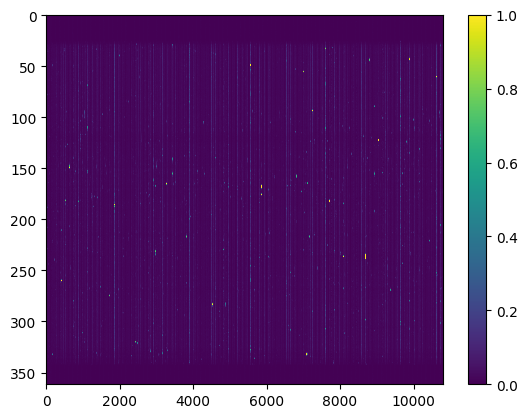

In [7]:
plt.imshow(all_data_reshaped[0], aspect='auto', interpolation='nearest')
plt.clim([0,1])
plt.colorbar()

In [8]:
op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids,
        two_thetas = two_theta,
        max_gb = 1.0,
        verbose=False)

Nx, Ny, K = op.Nx, op.Ny, op.K_sum

x_gpu = clarray.zeros(
    op.queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(op.queue, out_cpu)
# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
norm_sq = estimate_L_power(op, niter=1, seed=0, eps=1e-30, verbose=1)
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1e2, L=1.1*norm_sq, huber_delta=1.0)


solver.run(x_gpu, out_gpu, niter=1, verbose=1, diagnostics_interval=1)
coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]

[power 01] L_est=1.297508e+07  ||z||=3.675407e+08
[iter    1/1] obj=1.863210e+06  f=1.863210e+06  g=0.000000e+00  ||x||=5.547902e+01  ||grad||=7.918289e+08  tau=7.006e-08  beta=0.000e+00


In [9]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_Omega, Nx, N_eta, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_Omega, Nx, N_eta, N_theta))



In [10]:
def score_nodes(queue, op, node_indices, i_mat, sigma, res_peaks_gpu_summed):
    rotations = [tree.nodes[i].R for i in node_indices]
    grid_inv_cpu = invert_grid(rotations)
    grid_inv_gpu = clarray.to_device(queue, grid_inv_cpu)

    K = len(rotations)
    R = op.N_Omega
    C = op.N_eta
    P = op.N_peaks_list[i_mat]
    G = len(materials[i_mat].point_group_matrices)

    cutoff = 0.1 * 1.0 / (2*np.pi*sigma**2)

    sparse_pf = pfmatrix_sparseeval_gpu(
        queue,
        kernel_pfmatrix_count_sparse,
        kernel_pfmatrix_write_sparse,
        op.pf_coords_gpu_list[i_mat],
        grid_inv_gpu,
        op.pf_sym_ops_gpu_list[i_mat],
        op.pf_h_gpu_normed_list[i_mat],
        R, K, C, P, G,
        sigma,
        cutoff
    )

    IPs = sparse_pf_innerprod_gpu(
        queue,
        kernel_sparse_pf_innerprod_4d,
        sparse_pf,
        res_peaks_gpu_summed,
        R, C, P, K,
    )

    scores = IPs.get()
    scores = np.maximum(scores, 0)
    scores /= (scores.max() + 1e-12)

    for local_k, node_idx in enumerate(node_indices):
        tree.nodes[node_idx].score = float(scores[local_k])

    return scores


In [11]:
def refine_level(queue, op, tree, i_mat, level, res_peaks_gpu_summed=None):

    # --------------------------------------------------
    # 1. Score active leaf nodes at this level
    # --------------------------------------------------
    subgrid = tree.active_leaf_nodes_at_level(level)

    scores = score_nodes(
        queue, op,
        node_indices=subgrid,
        i_mat=i_mat,
        sigma=tree.sigma_levels[level],
        res_peaks_gpu_summed=res_peaks_gpu_summed,
    )

    # --------------------------------------------------
    # 2. Non-max suppression on SO(3)
    # --------------------------------------------------
    rotations = [tree.nodes[i].R for i in subgrid]
    delta = 1.5 * tree.sigma_levels[level]

    order = np.argsort(scores)[::-1]
    suppressed = np.zeros(len(subgrid), dtype=bool)
    selected_local = []

    for idx in order:
        if suppressed[idx]:
            continue
        if scores[idx] < 0.2:
            break

        selected_local.append(idx)
        Ri = rotations[idx]

        for j in order:
            if suppressed[j] or j == idx:
                continue
            d = np.linalg.norm((Ri.inv() * rotations[j]).as_rotvec())
            if d < delta:
                suppressed[j] = True

        if len(selected_local) >= 60:
            break

    parent_indices = [
        subgrid[i] for i in selected_local if scores[i] > 0.5
    ]

    # deactivate parents
    for p in parent_indices:
        tree.nodes[p].active = False

    # --------------------------------------------------
    # 3. Generate children
    # --------------------------------------------------
    new_children = tree.generate_children(
        parents=parent_indices,
        radius=tree.sigma_levels[level],
        stencil=12,
    )

    # --------------------------------------------------
    # 4. Score children
    # --------------------------------------------------
    child_scores = score_nodes(
        queue, op,
        node_indices=new_children,
        i_mat=i_mat,
        sigma=tree.sigma_levels[level + 1],
        res_peaks_gpu_summed=res_peaks_gpu_summed,
    )

    # --------------------------------------------------
    # 5. Prune children
    # --------------------------------------------------
    KEEP_PER_PARENT = 3
    MIN_SCORE = 0.3

    children_by_parent = {}
    for child_idx in new_children:
        p = tree.nodes[child_idx].parent
        children_by_parent.setdefault(p, []).append(child_idx)

    for parent, kids in children_by_parent.items():
        kids_sorted = sorted(
            kids, key=lambda i: tree.nodes[i].score, reverse=True
        )

        for i, k in enumerate(kids_sorted):
            tree.nodes[k].active = (
                i < KEEP_PER_PARENT and tree.nodes[k].score > MIN_SCORE
            )


In [12]:
grid_resolution_parameter = 11      # example
kernel_sigma = 0.15                # example
sigma_levels = [kernel_sigma, kernel_sigma/2, kernel_sigma/4, kernel_sigma/8]      # start with single level

grids = []

for mat in materials:
    tree = OrientationTree.from_hopf_fzone(
        mat.point_group_matrices,
        grid_resolution_parameter=grid_resolution_parameter,
        sigma_levels=sigma_levels,
    )
    grids.append(tree)

In [13]:
for i_mat in range(N_mat):
    theta_grid_gpu = clarray.to_device(op.queue, op.two_thetas)
    theta_peaks_gpu = clarray.to_device(op.queue, op.peak_positions_np_list[i_mat])

    res_peaks_gpu = clarray.empty(op.queue, (op.N_Omega, op.Nx, op.N_eta, op.N_peaks_list[i_mat]), dtype=np.float32, order="C")


    interp_theta_4d_gpu(
        op.queue,
        kernel_interp4d,
        res_gpu,
        res_peaks_gpu,
        theta_grid_gpu,
        theta_peaks_gpu,
        op.N_Omega, op.Nx, op.N_eta, op.N_theta, op.N_peaks_list[i_mat],
    )

    res_peaks_gpu_summed = clarray.empty(op.queue, (op.N_Omega, op.N_eta, op.N_peaks_list[i_mat]), dtype=np.float32, order="C")

    sum_over_x_gpu(op.queue, kernel_sum_over_x, res_peaks_gpu, res_peaks_gpu_summed, op.N_Omega, op.Nx, op.N_eta, op.N_peaks_list[i_mat])
    res_peaks_cpu = res_peaks_gpu_summed.get()
    res_peaks_cpu = res_peaks_cpu - res_peaks_cpu.mean(axis=1, keepdims=True)
    res_peaks_cpu = np.clip(res_peaks_cpu, a_min=0, a_max = 10000000)

    res_peaks_gpu_summed = clarray.to_device(op.queue, np.ascontiguousarray(res_peaks_cpu, dtype=np.float32))
    tree = grids[i_mat]

    refine_level(op.queue, op, tree, i_mat, 0, res_peaks_gpu_summed=res_peaks_gpu_summed)
    refine_level(op.queue, op, tree, i_mat, 1, res_peaks_gpu_summed=res_peaks_gpu_summed)
    refine_level(op.queue, op, tree, i_mat, 2, res_peaks_gpu_summed=res_peaks_gpu_summed)


In [14]:
op.K_list[0]

22

In [15]:
80+71+51+180

382

In [16]:
grids[0].print_summary()
lvl = 0
idx = tree.active_nodes_at_level(lvl)[2]
tree.inspect_node(idx)

OrientationTree summary:
  level 0: 182 active / 242 total
  level 1: 120 active / 720 total
  level 2: 120 active / 720 total
  level 3: 180 active / 720 total


{'index': 3,
 'level': 0,
 'active': True,
 'sigma': 0.15,
 'score': 0.2732999622821808,
 'parent': None,
 'children': [],
 'rotation_matrix': array([[ 0.64826523, -0.01686894, -0.76122772],
        [-0.74505081,  0.19210145, -0.6387459 ],
        [ 0.15700792,  0.98123008,  0.11196448]]),
 'rotvec': array([ 1.29200061, -0.73233246, -0.58075641])}

In [17]:

op.free_memory()
x_gpu.base_data.release()
out_gpu.base_data.release()

del x_gpu, out_gpu
gc.collect()



0

In [18]:
op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids,
        two_thetas = two_theta,
        max_gb=1.0,
        verbose=False,
        ctx = op.ctx,
        queue = op.queue)


Nx, Ny, K = op.Nx, op.Ny, op.K_sum

# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
norm_sq = estimate_L_power(op, niter=1, seed=0, eps=1e-30, verbose=1)
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1e2, L=1.1*norm_sq, huber_delta=2.0)

gc.collect()
x_gpu = clarray.zeros(
    op.queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_gpu = clarray.to_device(op.queue, out_cpu)

solver.run(x_gpu, out_gpu, niter=1, verbose=1, diagnostics_interval=1)
coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]


[power 01] L_est=1.065025e+09  ||z||=6.743382e+10
[iter    1/1] obj=1.863210e+06  f=1.863210e+06  g=0.000000e+00  ||x||=2.455121e+00  ||grad||=2.876241e+09  tau=8.536e-10  beta=0.000e+00


In [19]:
print(data_corrected.shape)

(181, 362, 90, 120)


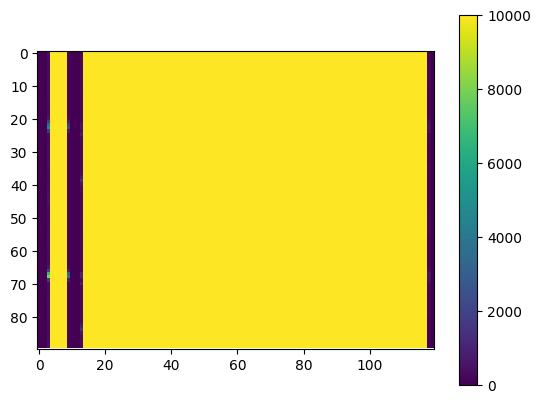

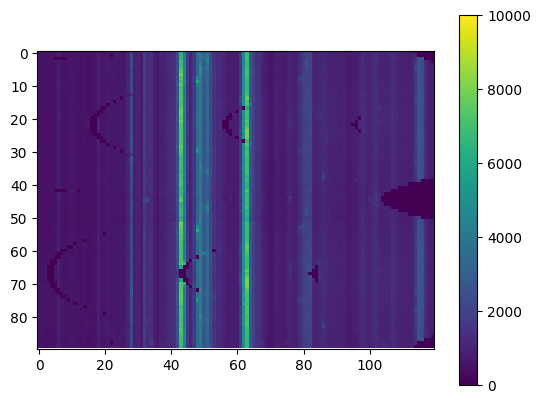

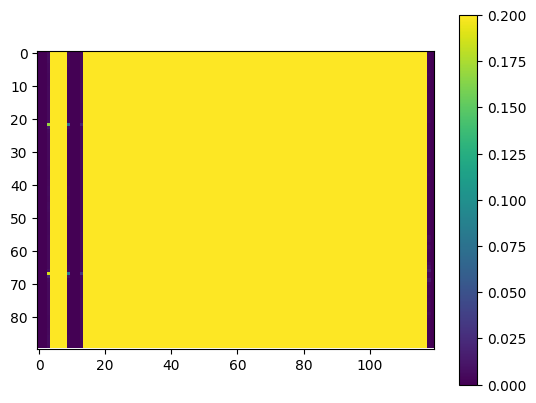

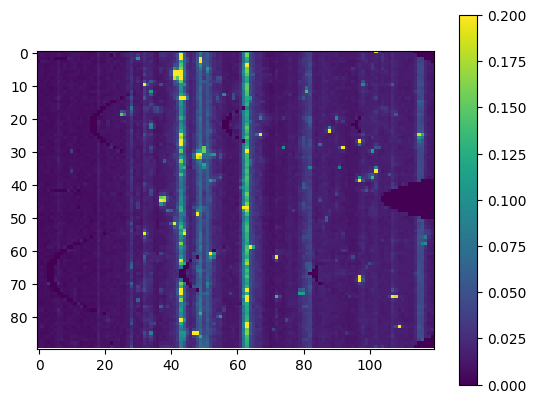

In [20]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_Omega, Nx, N_eta, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_Omega, Nx, N_eta, N_theta))

plt.imshow(prediction_cpu[:,:].sum(axis=(0,1)))
plt.colorbar()
plt.clim([0,50000*0.2])
plt.show()

plt.imshow(data_corrected[:,:].sum(axis=(0,1)))
plt.colorbar()
plt.clim([0,50000*0.2])
plt.show()

plt.imshow(prediction_cpu[0,180])
plt.colorbar()
plt.clim([0,0.2])
plt.show()

plt.imshow(data_corrected[0,180])
plt.colorbar()
plt.clim([0,0.2])
plt.show()

In [21]:
nod = grids[0].active_nodes_at_level(0)

In [22]:
with h5py.File('/work3/msaca/bbreconstruction.h5', "r") as f:
    dset = f["x"]
    coeffs = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(coeffs)

In [23]:
namelist = [
    "Spinel",
    "Diopside",
    "Hematite",
    "Ilmenite",
    "Baddeleyite",
    "Zircon",
    "Orthoclase",
    "Forsterite",
    "Albite",
    "Chlorapatite",
    "Ferrosilite",
    "Enstatite",
    "Chromite",
    "Pyrite",
    "Rutile",
]

/tmp/ipykernel_3072683/3322085216.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


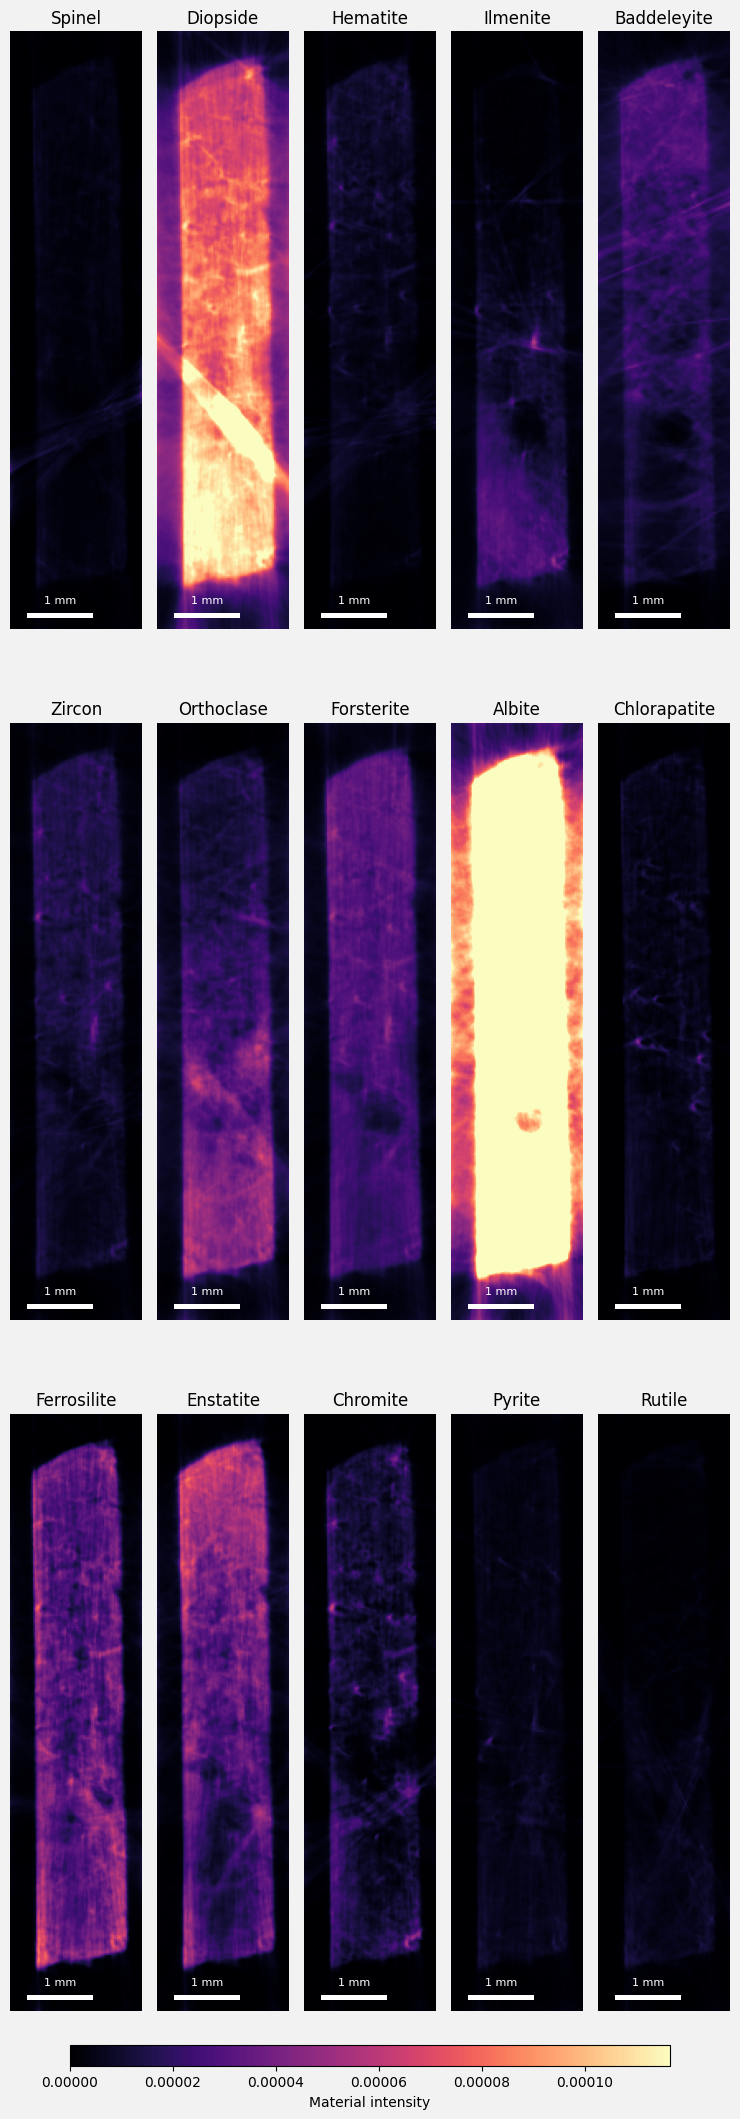

In [28]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- layout ----------
ncols = 5
nrows = 3
nplots = 15

# ---------- background ----------
plt.rcParams["figure.facecolor"] = "#f2f2f2"
plt.rcParams["axes.facecolor"] = "#f2f2f2"

# ---------- cumulative indices ----------
cumult_K_list = np.cumsum(
    np.concatenate([np.array([0]), np.array(op.K_list)])
)

# ---------- precompute all sumcoeffs for clim ----------
all_sumcoeffs = []
for i in range(nplots):
    sc = coeffs[:, :, cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1)
    all_sumcoeffs.append(sc)

all_vals = np.concatenate([a.ravel() for a in all_sumcoeffs])

vmin = np.min(all_vals)
vmax = 0.4*np.max(all_vals)

# ---------- figure ----------
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(1.5*ncols, 7*nrows),
    squeeze=False
)

images = []

# ---------- plotting ----------
for i in range(nplots):
    r = i // ncols
    c = i % ncols

    sumcoeffs = all_sumcoeffs[i]

    im = axes[r, c].imshow(
        sumcoeffs,
        cmap="magma",
        vmin=vmin,
        vmax=vmax
    )

    images.append(im)

    axes[r, c].set_title(namelist[i])
    axes[r, c].axis("off")

    # ----- scale bar -----
    bar_length_px = 40
    bar_height = 3

    y = sumcoeffs.shape[0] - 10
    x = 10

    rect = Rectangle(
        (x, y),
        bar_length_px,
        bar_height,
        facecolor="white",
        edgecolor="none"
    )
    axes[r, c].add_patch(rect)

    axes[r, c].text(
        x + bar_length_px / 2,
        y - 5,
        "1 mm",
        color="white",
        ha="center",
        va="bottom",
        fontsize=8
    )

# ---------- hide unused ----------
for i in range(nplots, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis("off")

# ---------- horizontal shared colorbar (lower) ----------

plt.tight_layout(rect=[0, 0.08, 1, 1])  # reserve bottom space

cax = fig.add_axes([0.1, 0.00, 0.8, 0.01])  
# [left, bottom, width, height] in figure fraction

cbar = fig.colorbar(images[0], cax=cax, orientation="horizontal")
cbar.set_label("Material intensity")

plt.tight_layout()
plt.savefig('/work3/msaca/material_map_vertical_highres.png', dpi = 500)
plt.show()



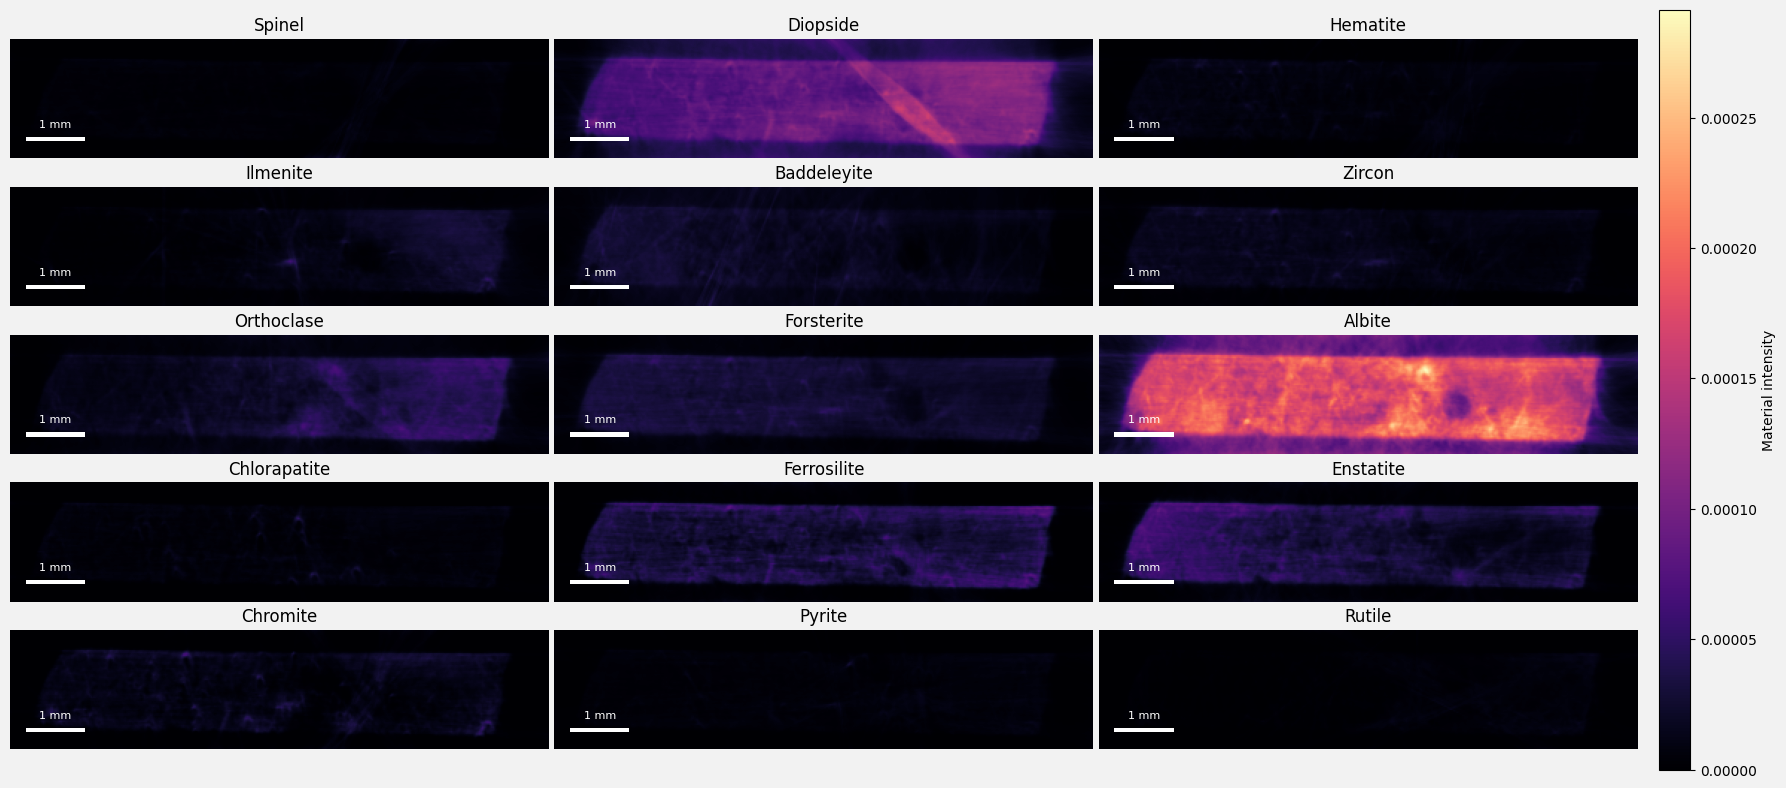

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- layout ----------
ncols = 3
nrows = 5
nplots = 15

# ---------- background ----------
plt.rcParams["figure.facecolor"] = "#f2f2f2"
plt.rcParams["axes.facecolor"] = "#f2f2f2"

# ---------- cumulative indices ----------
cumult_K_list = np.cumsum(
    np.concatenate([np.array([0]), np.array(op.K_list)])
)

# ---------- precompute all sumcoeffs for clim ----------
all_sumcoeffs = []
for i in range(nplots):
    sc = coeffs[:, :, cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1)
    all_sumcoeffs.append(sc)

all_vals = np.concatenate([a.ravel() for a in all_sumcoeffs])

vmin = np.min(all_vals)
vmax = np.max(all_vals)

# ---------- figure ----------
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7*ncols, 1.9*nrows),
    squeeze=False
)

images = []

# ---------- plotting ----------
for i in range(nplots):
    r = i // ncols
    c = i % ncols

    sumcoeffs = all_sumcoeffs[i]

    img = sumcoeffs.T

    im = axes[r, c].imshow(
        img,
        cmap="magma",
        vmin=vmin,
        vmax=vmax
    )

    images.append(im)

    axes[r, c].set_title(namelist[i])
    axes[r, c].axis("off")

    # ----- scale bar (fixed for transpose) -----
    bar_length_px = 40
    bar_height = 3

    y = img.shape[0] - 15
    x = 10

    rect = Rectangle(
        (x, y),
        bar_length_px,
        bar_height,
        facecolor="white",
        edgecolor="none"
    )
    axes[r, c].add_patch(rect)

    axes[r, c].text(
        x + bar_length_px / 2,
        y - 5,
        "1 mm",
        color="white",
        ha="center",
        va="bottom",
        fontsize=8
    )

# ---------- hide unused ----------
for i in range(nplots, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis("off")

# ---------- spacing control ----------
plt.subplots_adjust(hspace=0.05, wspace=0.01)

# ---------- vertical shared colorbar ----------
cax = fig.add_axes([0.91, 0.1, 0.015, 0.8])
cbar = fig.colorbar(images[0], cax=cax, orientation="vertical")
cbar.set_label("Material intensity")
plt.savefig('/work3/msaca/material_map_horizontal_highres.png', dpi = 500)
plt.show()




In [ ]:
#coeffs = coeffs*100

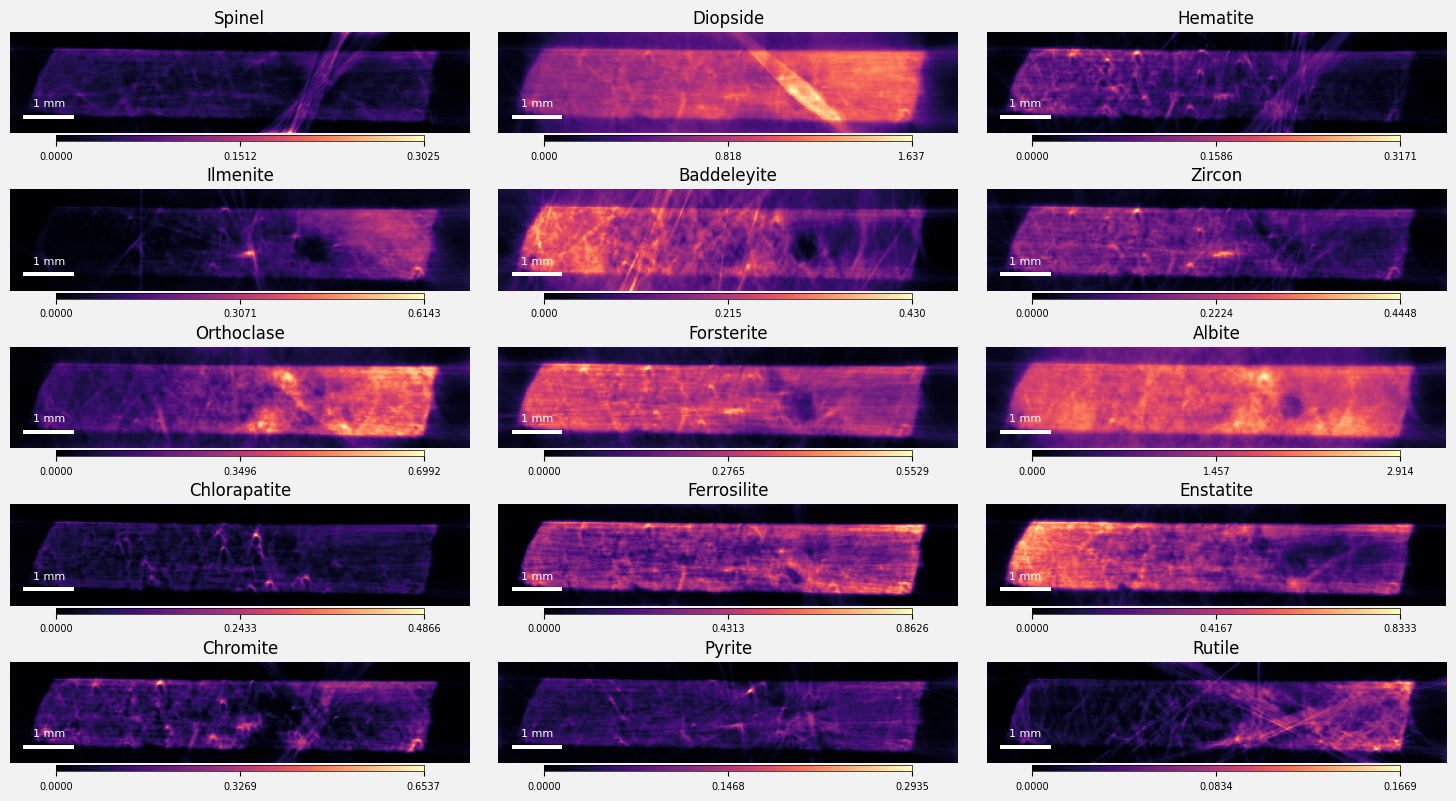

In [54]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ---------- layout ----------
ncols = 3
nrows = 5
nplots = 15

# ---------- background ----------
plt.rcParams["figure.facecolor"] = "#f2f2f2"
plt.rcParams["axes.facecolor"] = "#f2f2f2"

# ---------- cumulative indices ----------
cumult_K_list = np.cumsum(
    np.concatenate([np.array([0]), np.array(op.K_list)])
)

# ---------- precompute all sumcoeffs ----------
all_sumcoeffs = []
for i in range(nplots):
    sc = coeffs[:, :, cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1)
    all_sumcoeffs.append(sc)

all_vals = np.concatenate([a.ravel() for a in all_sumcoeffs])
vmin = np.min(all_vals)

# ---------- figure ----------
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7*ncols, 1.9*nrows),
    squeeze=False
)

# ---------- plotting ----------
for i in range(nplots):
    r = i // ncols
    c = i % ncols

    sumcoeffs = all_sumcoeffs[i]
    img = sumcoeffs.T

    vmax_i = np.max(img)

    im = axes[r, c].imshow(
        img,
        cmap="magma",
        vmin=vmin,
        vmax=vmax_i
    )

    axes[r, c].set_title(namelist[i])
    axes[r, c].axis("off")

    # ----- scale bar -----
    bar_length_px = 40
    bar_height = 3

    y = img.shape[0] - 15
    x = 10

    rect = Rectangle(
        (x, y),
        bar_length_px,
        bar_height,
        facecolor="white",
        edgecolor="none"
    )
    axes[r, c].add_patch(rect)

    axes[r, c].text(
        x + bar_length_px / 2,
        y - 5,
        "1 mm",
        color="white",
        ha="center",
        va="bottom",
        fontsize=8
    )

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cax = inset_axes(
        axes[r, c],
        width="80%",      # bar width relative to subplot
        height="6%",
        loc="lower center",
        bbox_to_anchor=(0, -0.08, 1, 1),   # <-- moves it below the plot
        bbox_transform=axes[r, c].transAxes,
        borderpad=0
    )

    cb = fig.colorbar(im, cax=cax, orientation="horizontal")

    mid = 0.5 * (vmin + vmax_i)
    cb.set_ticks([vmin, mid, vmax_i])
    cb.ax.tick_params(labelsize=7)
    cb.outline.set_linewidth(0.5)


# ---------- hide unused ----------
for i in range(nplots, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis("off")

# ---------- spacing ----------
plt.subplots_adjust(hspace=0.55, wspace=-0.25)

plt.savefig('/work3/msaca/material_map_horizontal_highres.png', dpi=500, bbox_inches='tight')
plt.show()



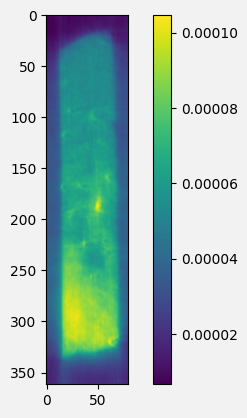

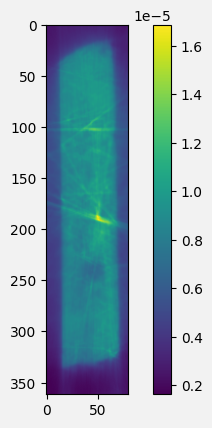

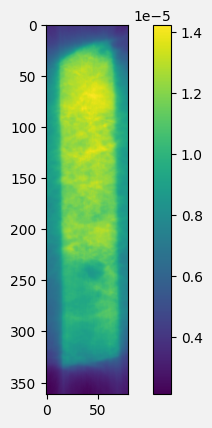

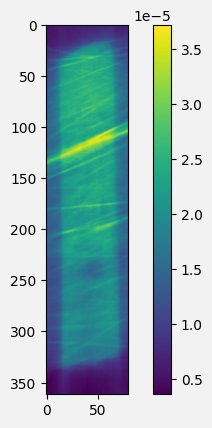

In [90]:
i = 3


all_levels = []
for i_level in range(0,4):
    all_sumcoeffs = []
    for i_mat in range(op.N_mat):
        index_level = np.array(grids[i].active_nodes_at_level(i_level)) + op.offsets[i]
        sc = coeffs[:, :, index_level].sum(axis=-1)
        all_sumcoeffs.append(sc)
    all_sumcoeffs = np.stack(all_sumcoeffs)
    all_sumcoeffs = all_sumcoeffs.sum(axis=0)
    all_levels.append(all_sumcoeffs)

plt.imshow(all_levels[0])
plt.colorbar()
plt.show()
plt.imshow(all_levels[1])
plt.colorbar()
plt.show()
plt.imshow(all_levels[2])
plt.colorbar()
plt.show()
plt.imshow(all_levels[3])
plt.colorbar()
plt.show()

In [97]:
print(op.K_list)

[ 382 1688  797  842 1713  680 1658 1027 3216  528 1024 1030  452  464
  684]


In [ ]:
print(coeffs_material.shape)
print(op.offsets[0])


(362, 80, 842)
0


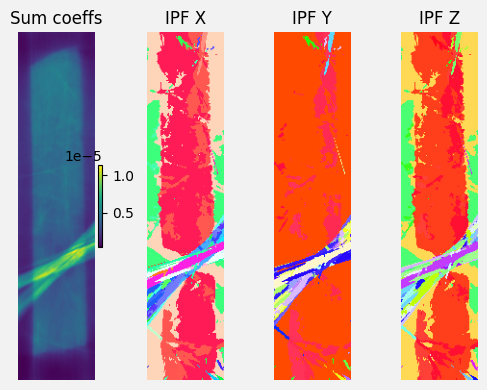

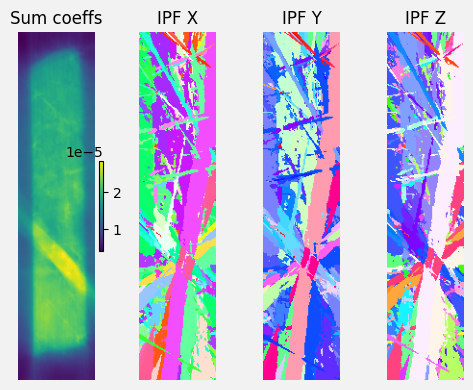

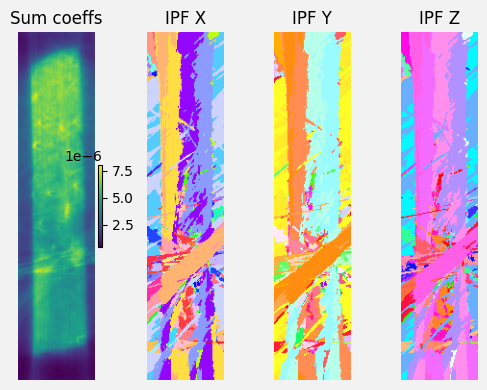

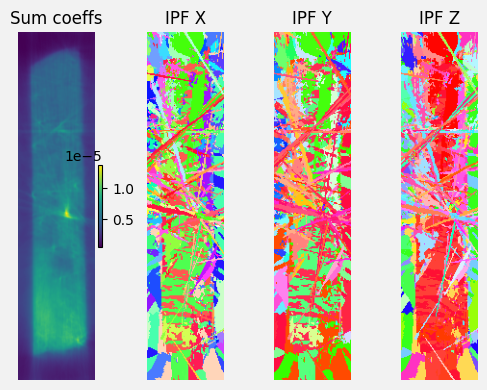

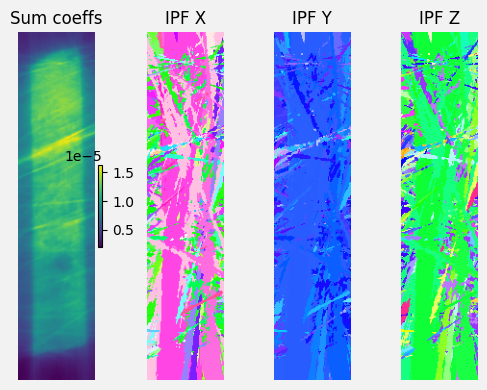

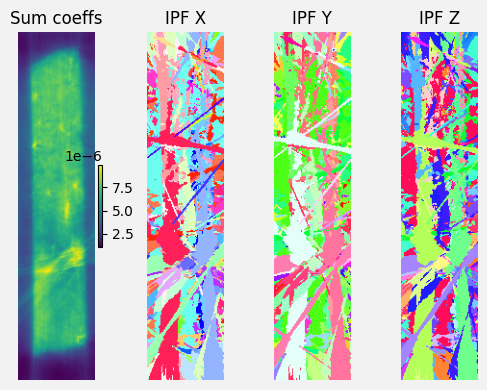

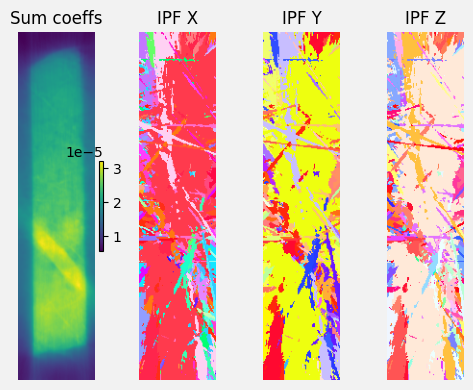

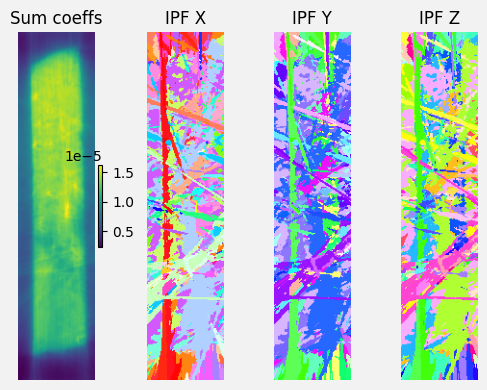

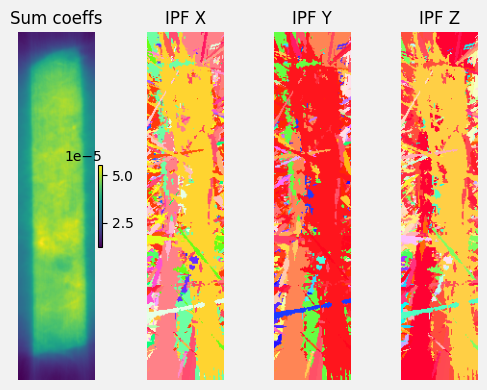

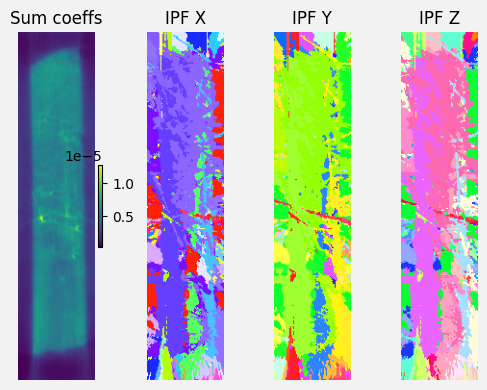

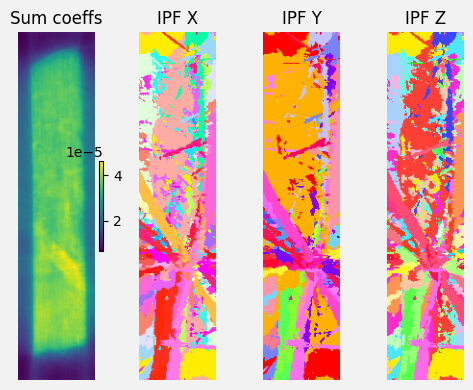

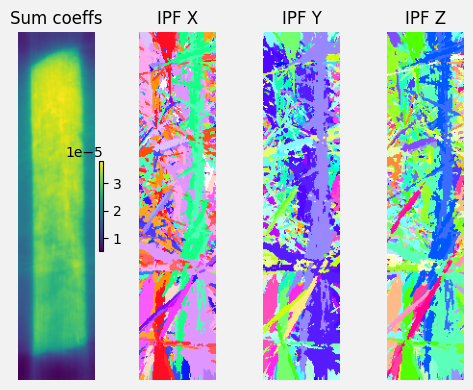

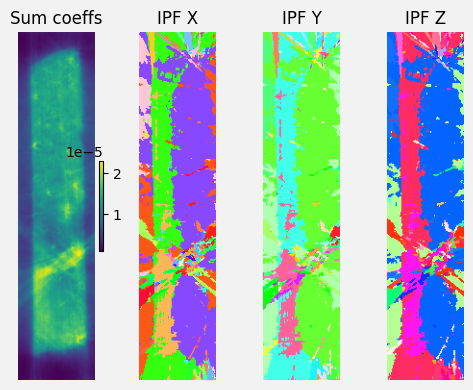

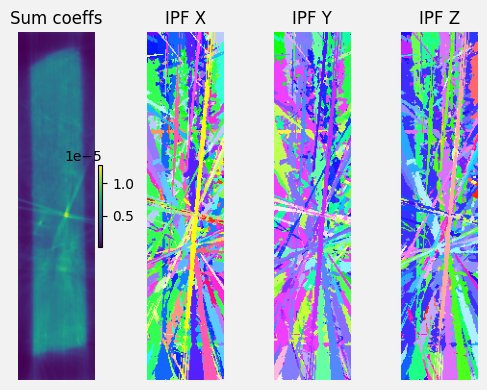

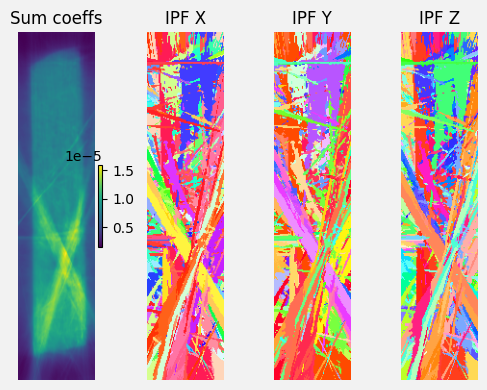

In [117]:
for i_mat in range(op.N_mat):
    from scipy.spatial.transform import Rotation as R
    import matplotlib.pyplot as plt

    grid = grids[i_mat]
    coeffs_material = coeffs[:, :, op.offsets[i_mat]:op.offsets[i_mat] + op.K_list[i_mat]]

    indices = grid.active_leaf_nodes()
    grid_sp = [grid.nodes[i].R for i in indices]
    grid_sp = R.concatenate(grid_sp)

    stepsize = 0.004

    mask = coeffs.sum(axis=2) > 0

    fig, axes = plt.subplots(1, 4, figsize=(5, 4))

    # --- plot 1: sum of coeffs ---
    im0 = axes[0].imshow(coeffs_material.sum(axis=2))
    axes[0].set_title("Sum coeffs")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # ---------- helper for IPF plotting ----------
    def plot_ipf(ax, direction, title):

        ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(direction))
        orientations = Orientation.from_scipy_rotation(grid_sp)
        orientations.symmetry = ipfkey.symmetry

        rgb = ipfkey.orientation2color(orientations)[
            np.argmax(coeffs_material, axis=-1)
        ]

        rgb[~mask] *= 0

        ax.imshow(rgb)
        ax.set_title(title)
        ax.axis("off")

    # --- plot 2,3,4 ---
    plot_ipf(axes[1], [1,0,0], "IPF X")
    plot_ipf(axes[2], [0,1,0], "IPF Y")
    plot_ipf(axes[3], [0,0,1], "IPF Z")

    plt.tight_layout()
    plt.show()
